# Full experiment description (one-hot)

## Importing and preparation

In [1]:
import sys
import os
from pathlib import Path
from omegaconf import OmegaConf
import pandas as pd

project_root = Path().absolute().parent
sys.path.append(str(project_root))

### Path preparation

In [2]:
%cd ..

/Users/alex/Edu/Bioinformatics_institute/Project/Vlasova/gitlab


/Users/alex/miniconda3/envs/tcreppred_sil2/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
output_dir = 'full_exp_onehot'
weights_suf = 'weights'
report_suf = 'report'
embds_suf = 'embds'

## Import TCRenc scripts

In [4]:
from tcrenc.tcrenc_run import main as tcrenc_run_main
from tcrenc.tcrenc_train import main as tcrenc_train_main
from tcrenc.tcrenc_validate import main as tcrenc_validate_main

/Users/alex/miniconda3/envs/tcreppred_sil2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## One-hot sequence representation experiment

Let's try to train autoencoder for one-hot representation.
General pipeline:
```
1.configure model parameters ->  2. train model ->  3. Validate it on some test data -> 4. Make embeddings for future use
```

### 1.Model configuration

In [5]:
with open('./tcrenc/configs/config_general.yaml') as f:
    general_config = OmegaConf.load(f)
print('General configurations:\n', general_config)

with open('./tcrenc/configs/config_onehot.yaml') as f:
    special_config = OmegaConf.load(f)
print('Special models configurations:\n', special_config)

General configurations:
 {'USE_GPU': True, 'LATENT_DIMS': 64, 'MIN_CDR3_LEN': 11, 'MAX_CDR3_LEN': 19, 'MAX_EPITOPE_LEN': 20, 'MIN_EPITOPE_LEN': 6}
Special models configurations:
 {'general': {'BATCH_SIZE': 400, 'LOSS_FUNCTION': {'_component_': 'torch.nn.CrossEntropyLoss'}}, 'train': {'EPOCH_NUM': 200, 'OPTIMIZER': {'_component_': 'torch.optim.Adam', 'lr': 0.0001, 'weight_decay': 0}}, 'validate': {'WEIGHTS_CDR3': 'tcrenc/models/autoencoder_onehot/weights/cdr3_model_final_restructed.pth', 'WEIGHTS_EPIOPE': './tcrenc/models/autoencoder_onehot/weights/epitope_model_final_restructed.pth'}, 'run': {'WEIGHTS_CDR3': './tcrenc/models/autoencoder_onehot/weights/cdr3_model_final_restructed.pth', 'WEIGHTS_EPIOPE': './tcrenc/models/autoencoder_onehot/weights/epitope_model_final_restructed.pth'}}


* You can change parameters manually, or reassign some values here and save the dictionaries to the path specified below.

In [6]:
# with open('./tcrenc/configs/config_general.yaml') as f:
#     general_config = OmegaConf.load(f)

# # Update
# general_config['LATENT_DIMS'] = 64

# with open('./tcrenc/configs/config_general.yaml', 'w') as f:
#     OmegaConf.save(general_config, f)

### 2. Model training 

#### Prepare training data

For epitope training we will use data from IEDB with following filters:
- linear peptides
- host: human

For cdr3 training we will use VDJdb.

#### Epitope model train

In [7]:
script_name = 'tcrenc_train'

val_args = {
  "--input":'./dataset/epitopes_for_train/epitopes.csv',
  '--embed_type':'onehot',
  '--output':os.path.join(output_dir, weights_suf),
  '--split': '0.8'
}
logic_args = [
    "--weights_save"
    #'--cdr',
    #'--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [8]:
tcrenc_train_main(sys.argv)

Training model for antigen_epitope ...
[0/200] Train Loss: 1.9741 | Test Loss: 1.6279
[20/200] Train Loss: 0.2374 | Test Loss: 0.2464
[40/200] Train Loss: 0.1683 | Test Loss: 0.1818
[60/200] Train Loss: 0.1227 | Test Loss: 0.1373
[80/200] Train Loss: 0.0903 | Test Loss: 0.1045
[100/200] Train Loss: 0.0662 | Test Loss: 0.0793
[120/200] Train Loss: 0.0484 | Test Loss: 0.0603
[140/200] Train Loss: 0.0354 | Test Loss: 0.0464
[160/200] Train Loss: 0.0256 | Test Loss: 0.0358
[180/200] Train Loss: 0.0180 | Test Loss: 0.0272
Train for antigen_epitope finished


#### Update weights in config

In [9]:
with open('./tcrenc/configs/config_onehot.yaml') as f:
    special_config = OmegaConf.load(f)

old_ep_weights = special_config['validate']['WEIGHTS_EPIOPE']
# Update
special_config['validate']['WEIGHTS_EPIOPE'] = os.path.join(output_dir, weights_suf, 'weights_onehot_antigen_epitope.pth')

with open('./tcrenc/configs/config_onehot.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

#### CDR3 model train

In [10]:
script_name = 'tcrenc_train'

val_args = {
  "--input":'VDJdb',
  '--embed_type':'onehot',
  '--output':os.path.join(output_dir, weights_suf),
  '--split': '0.8'
}
logic_args = [
    "--weights_save",
    '--cdr',
    #'--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [11]:
tcrenc_train_main(sys.argv)

Training model for cdr3 ...
[0/200] Train Loss: 2.2971 | Test Loss: 1.6210
[20/200] Train Loss: 0.1339 | Test Loss: 0.1292
[40/200] Train Loss: 0.0346 | Test Loss: 0.0383
[60/200] Train Loss: 0.0186 | Test Loss: 0.0244
[80/200] Train Loss: 0.0120 | Test Loss: 0.0190
[100/200] Train Loss: 0.0082 | Test Loss: 0.0160
[120/200] Train Loss: 0.0057 | Test Loss: 0.0140
[140/200] Train Loss: 0.0040 | Test Loss: 0.0127
[160/200] Train Loss: 0.0029 | Test Loss: 0.0118
[180/200] Train Loss: 0.0020 | Test Loss: 0.0111
Train for cdr3 finished


#### Update weights in config

In [12]:
with open('./tcrenc/configs/config_onehot.yaml') as f:
    special_config = OmegaConf.load(f)

old_cdr_weights = special_config['validate']['WEIGHTS_CDR3']
# Update
special_config['validate']['WEIGHTS_CDR3'] = os.path.join(output_dir, weights_suf,'weights_onehot_cdr3.pth')

with open('./tcrenc/configs/config_onehot.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

### 3. Model validation 

In [13]:
script_name = 'tcrenc_validate'

val_args = {
  "--input":'VDJdb',
  '--embed_type':'onehot',
  '--output':os.path.join(output_dir, report_suf),
}
logic_args = [
    # "--weights_save",
    # '--cdr',
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

Average reconstruction error of cdr3 sequences on sample: 0.0033
Average reconstruction error of antigen_epitope sequences on sample: 0.0024
All files saved!


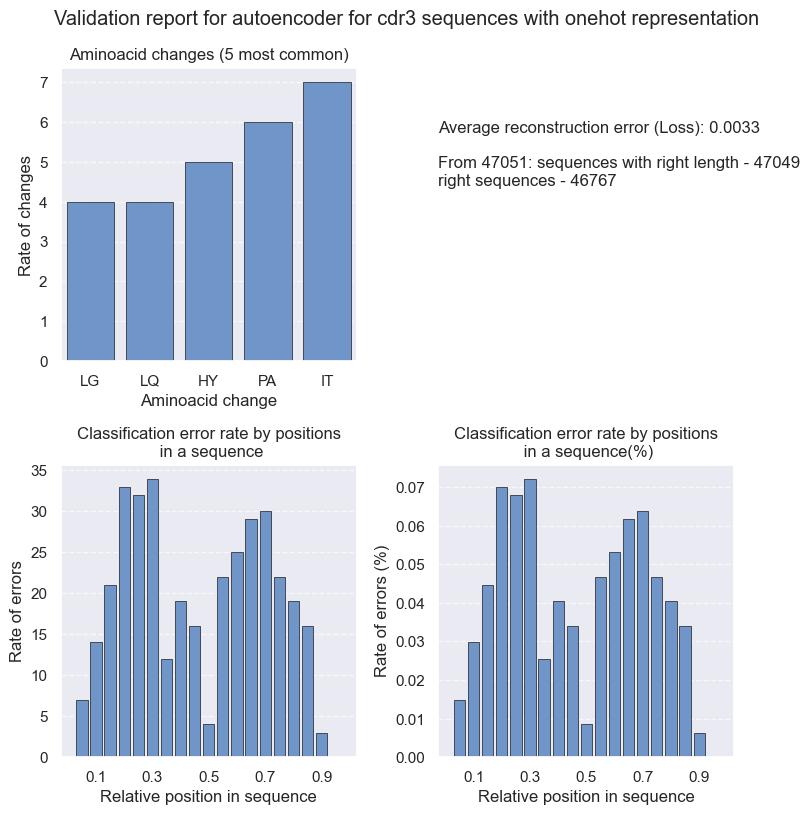

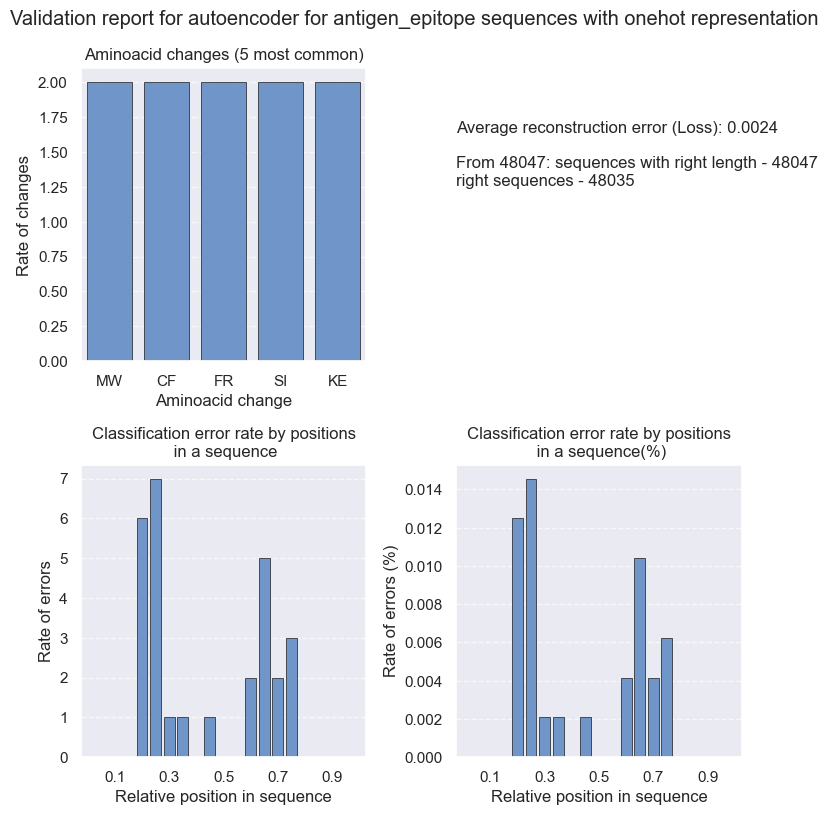

In [14]:
tcrenc_validate_main(sys.argv)

### 4. Make embeddings with trained model

#### Update config

In [15]:
with open('./tcrenc/configs/config_onehot.yaml') as f:
    special_config = OmegaConf.load(f)

# Update
special_config['run']['WEIGHTS_EPIOPE'] = os.path.join(output_dir, weights_suf, 'weights_onehot_antigen_epitope.pth')
special_config['run']['WEIGHTS_CDR3'] = os.path.join(output_dir, weights_suf,'weights_onehot_cdr3.pth')

with open('./tcrenc/configs/config_onehot.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

#### Make embeddings

In [16]:
script_name = 'tcrenc_run'

val_args = {
  "--input": 'VDJdb',
  '--embed_type':'onehot',
  '--output':os.path.join(output_dir, embds_suf),
}
logic_args = [
    # '--decoder',
    # '--cdr',
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [17]:
tcrenc_run_main(sys.argv)

full_exp_onehot/embds/embeddings_cdr3_onehot.csv file saved!
full_exp_onehot/embds/embeddings_antigen_epitope_onehot.csv file saved!
All files saved!


#### Use new embeddings to reconstruct sequences (Use our model as decoder)

In [18]:
df = pd.read_csv(os.path.join(output_dir, embds_suf, 'embeddings_cdr3_onehot.csv'))
df.drop(columns='cdr3', inplace=True)
df.to_csv(os.path.join(output_dir, embds_suf, 'embeddings_cdr3_onehot_for_decoder.csv'), index=False)

In [19]:
script_name = 'tcrenc_run'

val_args = {
  "--input": os.path.join(output_dir, embds_suf, 'embeddings_cdr3_onehot_for_decoder.csv'),
  '--embed_type':'onehot',
  '--output':os.path.join(output_dir, embds_suf),
}
logic_args = [
    '--decoder',
    '--cdr',
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [20]:
tcrenc_run_main(sys.argv)

full_exp_onehot/embds/reconstructed_cdr3_onehot.csv file saved!
All files saved!


#### Re-update weights

In [21]:
with open('./tcrenc/configs/config_onehot.yaml') as f:
    special_config = OmegaConf.load(f)

# Update
special_config['run']['WEIGHTS_EPIOPE'] = old_ep_weights
special_config['validate']['WEIGHTS_EPIOPE'] = old_ep_weights
special_config['run']['WEIGHTS_CDR3'] = old_cdr_weights
special_config['validate']['WEIGHTS_CDR3'] = old_cdr_weights 

with open('./tcrenc/configs/config_onehot.yaml', 'w') as f:
    OmegaConf.save(special_config, f)